Epoch 1/10 | Train Loss: 0.4430 | Val Loss: 0.5653 | Train Dice: 0.6444 | Val Dice: 0.0000
Epoch 2/10 | Train Loss: 0.3047 | Val Loss: 0.3939 | Train Dice: 0.8722 | Val Dice: 0.0000
Epoch 3/10 | Train Loss: 0.2451 | Val Loss: 0.2774 | Train Dice: 0.8925 | Val Dice: 0.0199
Epoch 4/10 | Train Loss: 0.1702 | Val Loss: 0.1591 | Train Dice: 0.9029 | Val Dice: 0.7985
Epoch 5/10 | Train Loss: 0.1242 | Val Loss: 0.2206 | Train Dice: 0.8906 | Val Dice: 0.6132
Epoch 6/10 | Train Loss: 0.0996 | Val Loss: 0.0870 | Train Dice: 0.8918 | Val Dice: 0.9512
Epoch 7/10 | Train Loss: 0.0755 | Val Loss: 0.0723 | Train Dice: 0.9228 | Val Dice: 0.9392
Epoch 8/10 | Train Loss: 0.0572 | Val Loss: 0.0554 | Train Dice: 0.9343 | Val Dice: 0.9563
Epoch 9/10 | Train Loss: 0.0478 | Val Loss: 0.0389 | Train Dice: 0.9216 | Val Dice: 0.9575
Epoch 10/10 | Train Loss: 0.0391 | Val Loss: 0.0354 | Train Dice: 0.9304 | Val Dice: 0.9517


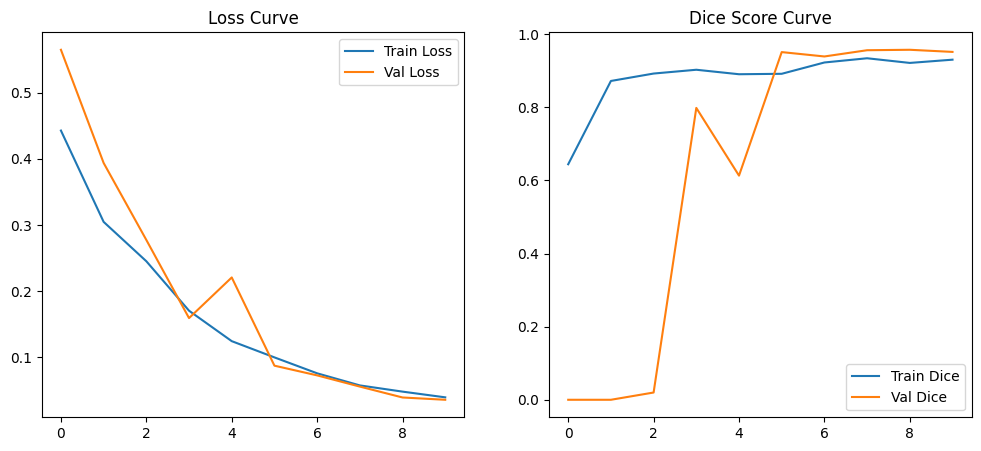


 Dice moyen final : 0.8838


In [1]:

# import os
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset
# import numpy as np
# from PIL import Image
# import matplotlib.pyplot as plt

# # -------------------------
# # 1. Dataset
# # -------------------------
# class SegmentationDataset(Dataset):
#     def __init__(self, images_dir, masks_dir):
#         self.image_paths = sorted([os.path.join(images_dir, f) 
#                                    for f in os.listdir(images_dir) if f.endswith(".png")])
#         self.mask_paths = sorted([os.path.join(masks_dir, f) 
#                                   for f in os.listdir(masks_dir) if f.endswith(".png")])

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         image = np.array(Image.open(self.image_paths[idx]).convert("L"), dtype=np.float32) / 255.0
#         mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32) / 255.0
        
#         image = torch.from_numpy(image).unsqueeze(0)
#         mask = torch.from_numpy(mask).unsqueeze(0)

#         return image, mask

# # -------------------------
# # 2. UNet (identique à entraînement)
# # -------------------------
# class UNet(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.enc1 = self.conv_block(1, 64)
#         self.enc2 = self.conv_block(64, 128)
#         self.pool = nn.MaxPool2d(2)

#         self.bottleneck = self.conv_block(128, 256)

#         self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
#         self.dec2 = self.conv_block(256, 128)

#         self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
#         self.dec1 = self.conv_block(128, 64)

#         self.final = nn.Conv2d(64, 1, 1)

#     def conv_block(self, in_ch, out_ch):
#         return nn.Sequential(
#             nn.Conv2d(in_ch, out_ch, 3, padding=1),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_ch, out_ch, 3, padding=1),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         x1 = self.enc1(x)
#         x2 = self.enc2(self.pool(x1))

#         x3 = self.bottleneck(self.pool(x2))

#         x = self.up2(x3)
#         x = torch.cat([x, x2], dim=1)
#         x = self.dec2(x)

#         x = self.up1(x)
#         x = torch.cat([x, x1], dim=1)
#         x = self.dec1(x)

#         return torch.sigmoid(self.final(x))

# # -------------------------
# # 3. Dice Score
# # -------------------------
# def dice_score(pred, target):
#     pred = (pred > 0.5).float()
#     intersection = (pred * target).sum()
#     return (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

# # -------------------------
# # 4. Charger modèle
# # -------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = UNet().to(device)
# model.load_state_dict(torch.load("model.pth", map_location=device))
# model.eval()

# print(" Modèle chargé")

# # -------------------------
# # 5. Dataset
# # -------------------------
# images_dir = "data/images"
# masks_dir = "data/masks"

# dataset = SegmentationDataset(images_dir, masks_dir)
# print(f" Nombre d'images : {len(dataset)}")

# # dossier résultats
# os.makedirs("results", exist_ok=True)

# # -------------------------
# # 6. Visualisation + évaluation
# # -------------------------
# total_dice = 0

# for i in range(len(dataset)):
#     img, mask = dataset[i]
#     img_tensor = img.unsqueeze(0).to(device).float()

#     with torch.no_grad():
#         pred = model(img_tensor)

#     pred_cpu = pred.cpu()

#     # Calcul Dice
#     dice = dice_score(pred_cpu, mask)
#     total_dice += dice.item()

#     #  VISUALISATION
#     image = img.squeeze().numpy()
#     mask_np = mask.squeeze().numpy()
#     pred_np = pred_cpu.squeeze().numpy()

#     plt.figure(figsize=(12,4))

#     plt.subplot(1,3,1)
#     plt.title("Image")
#     plt.imshow(image, cmap='gray')

#     plt.subplot(1,3,2)
#     plt.title("Mask réel")
#     plt.imshow(mask_np, cmap='gray')

#     plt.subplot(1,3,3)
#     plt.title(f"Prediction (Dice={dice:.3f})")
#     plt.imshow(pred_np > 0.5, cmap='gray')

#     plt.tight_layout()

#     # Sauvegarde au lieu d'afficher uniquement
#     plt.savefig(f"results/result_{i}.png")
#     plt.close()

#     # Afficher seulement quelques images (évite 1000 fenêtres)
#     if i < 5:
#         plt.figure(figsize=(12,4))
#         plt.subplot(1,3,1)
#         plt.imshow(image, cmap='gray')
#         plt.subplot(1,3,2)
#         plt.imshow(mask_np, cmap='gray')
#         plt.subplot(1,3,3)
#         plt.imshow(pred_np > 0.5, cmap='gray')
#         plt.title(f"Dice={dice:.3f}")
#         plt.show()

# # -------------------------
# # 7. Résultat global
# # -------------------------
# mean_dice = total_dice / len(dataset)
# print(f"\n Dice moyen sur tout le dataset : {mean_dice:.4f}")



import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# 1. Dataset
# -------------------------
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.image_paths = sorted([os.path.join(images_dir, f) 
                                   for f in os.listdir(images_dir) if f.endswith(".png")])
        self.mask_paths = sorted([os.path.join(masks_dir, f) 
                                  for f in os.listdir(masks_dir) if f.endswith(".png")])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("L"), dtype=np.float32) / 255.0
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32) / 255.0
        
        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

# -------------------------
# 2. UNet
# -------------------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = self.conv_block(1, 64)
        self.enc2 = self.conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = self.conv_block(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))

        x3 = self.bottleneck(self.pool(x2))

        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        return torch.sigmoid(self.final(x))

# -------------------------
# 3. Dice Score
# -------------------------
def dice_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

# -------------------------
# 4. Setup
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images_dir = "data/images"
masks_dir = "data/masks"

dataset = SegmentationDataset(images_dir, masks_dir)

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = UNet().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# 5. Training
# -------------------------
num_epochs = 10

train_losses = []
val_losses = []
train_dices = []
val_dices = []

best_dice = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_dice = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(preds.detach(), masks).item()

    train_losses.append(train_loss / len(train_loader))
    train_dices.append(train_dice / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = criterion(preds, masks)

            val_loss += loss.item()
            val_dice += dice_score(preds, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dices.append(val_dice / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | "
          f"Train Dice: {train_dices[-1]:.4f} | Val Dice: {val_dices[-1]:.4f}")

    # Save best model
    if val_dices[-1] > best_dice:
        best_dice = val_dices[-1]
        torch.save(model.state_dict(), "best_model.pth")

# -------------------------
# 6. Courbes
# -------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dices, label="Train Dice")
plt.plot(val_dices, label="Val Dice")
plt.title("Dice Score Curve")
plt.legend()

plt.savefig("learning_curve.png")
plt.show()

# -------------------------
# 7. Test + Visualisation
# -------------------------
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

os.makedirs("results", exist_ok=True)

total_dice = 0

for i in range(len(dataset)):
    img, mask = dataset[i]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)

    pred_cpu = pred.cpu()

    dice = dice_score(pred_cpu, mask)
    total_dice += dice.item()

    image = img.squeeze().numpy()
    mask_np = mask.squeeze().numpy()
    pred_np = pred_cpu.squeeze().numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image, cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Mask réel")
    plt.imshow(mask_np, cmap='gray')

    plt.subplot(1,3,3)
    plt.title(f"Prediction (Dice={dice:.3f})")
    plt.imshow(pred_np > 0.5, cmap='gray')

    plt.tight_layout()
    plt.savefig(f"results/result_{i}.png")
    plt.close()

# Résultat final
mean_dice = total_dice / len(dataset)
print(f"\n Dice moyen final : {mean_dice:.4f}")